In [1]:

import os
import pandas as pd
from collections import defaultdict

guide_file = "01_make_simulations_output/guides.txt"
sample_file = "01_make_simulations_output/samples.txt"
aggregated_stats_file = "02_run_output/aggregated_stats_all.txt"

samples = pd.read_csv(sample_file, sep="\t")
samples["replicate"] = pd.to_numeric(samples["replicate"], errors="coerce")
samples

,Name,r1,Group,background_noise_rate,replicate
0,sample_0_edited_0_noise_rep0,01_make_simulations_output/sample_0_edited_0_n...,edited,0.00,0
1,sample_1_unedited_0_noise_rep0,01_make_simulations_output/sample_1_unedited_0...,unedited,0.00,0
2,sample_2_edited_0.01_noise_rep0,01_make_simulations_output/sample_2_edited_0.0...,edited,0.01,0
3,sample_3_unedited_0.01_noise_rep0,01_make_simulations_output/sample_3_unedited_0...,unedited,0.01,0
4,sample_4_edited_0.05_noise_rep0,01_make_simulations_output/sample_4_edited_0.0...,edited,0.05,0
5,sample_5_unedited_0.05_noise_rep0,01_make_simulations_output/sample_5_unedited_0...,unedited,0.05,0
6,sample_6_edited_0.1_noise_rep0,01_make_simulations_output/sample_6_edited_0.1...,edited,0.10,0
7,sample_7_unedited_0.1_noise_rep0,01_make_simulations_output/sample_7_unedited_0...,unedited,0.10,0
8,sample_8_edited_0_noise_rep1,01_make_simulations_output/sample_8_edited_0_n...,edited,0.00,1
9,sample_9_unedited_0_noise_rep1,01_make_simulations_output/sample_9_unedited_0...,unedited,0.00,1


In [2]:
samples["noise_rate_label"] = samples["Name"].str.extract(r"_(?:edited|unedited)_([^_]+)_noise")
background_noise_labels = sorted(samples["noise_rate_label"].dropna().unique(), key=float)

replicate_counts = [3,5]

output_folder = "03_make_replots.ipynb.output"
if not os.path.exists(output_folder):
    os.makedirs(output_folder)

sig_tests = [("hard_cutoff","hard_cutoff,0.01"),
             ("mean_diff","mean_diff,edited,unedited,0.01"),
             ("t_test","t_test,edited,unedited,0.05"),
             ("mann_whitney","mann_whitney,edited,unedited,0.05"),
             ("neg_binomial","neg_binomial,edited,unedited,0.05")]

command_file = os.path.join(output_folder, "commands.txt")
sig_test_outputs = defaultdict(list)
with open(command_file, 'w') as f:
    for replicate_number in replicate_counts:
        rep_samples = samples[samples['replicate'] < replicate_number]
        for background_noise_label in background_noise_labels:
            background_mutation_rate = float(background_noise_label)
            edited_samples = [x for x in rep_samples['Name'] if f"_edited_{background_noise_label}_noise" in x]
            unedited_samples = [x for x in rep_samples['Name'] if f"_unedited_{background_noise_label}_noise" in x]
            sub_sample_file = os.path.join(output_folder, f"noise_{background_noise_label}_reps_{replicate_number}.agg_samples.txt")
            with open(sub_sample_file, 'w') as bg_f:
                bg_f.write("Name\tfastq_r1\tGroup\n")
                for sample in edited_samples:
                    bg_f.write(f'{sample}\t{samples.loc[samples["Name"] == sample, "r1"].values[0]}\tedited\n')
                for sample in unedited_samples:
                    bg_f.write(f'{sample}\t{samples.loc[samples["Name"] == sample, "r1"].values[0]}\tunedited\n')
            f.write(f'CRISPRessoSea Replot --reordered_stats_file {aggregated_stats_file} --reordered_sample_file {sub_sample_file} --output_folder {output_folder}/noise_{background_noise_label}_reps_{replicate_number}\n')
            for sig_test_name, sig_test_string in sig_tests:
                test_output_folder = os.path.join(output_folder, f"noise_{background_noise_label}_reps_{replicate_number}_{sig_test_name}")
                f.write(f'CRISPRessoSea Replot --reordered_stats_file {aggregated_stats_file} --reordered_sample_file {sub_sample_file} --output_folder {test_output_folder} --sig_method_parameters {sig_test_string}\n')
                sig_test_outputs[sig_test_name].append(test_output_folder)

In [3]:
aggregated_stats = pd.read_csv(aggregated_stats_file, sep="\t").copy()
aggregated_stats["editing_rate"] = aggregated_stats["target_name"].str.split("EditingRate").str[-1].astype(float)
samples_for_replot = samples.copy()

hard_cutoff_string = dict(sig_tests)["hard_cutoff"]
hard_cutoff_threshold = float(hard_cutoff_string.split(",")[1])
hard_cutoff_pct = hard_cutoff_threshold if hard_cutoff_threshold > 1 else hard_cutoff_threshold

sig_test_summary_tables = {}

for sig_test_name, test_output_folders in sig_test_outputs.items():
    summary_rows = []

    for test_output_folder in test_output_folders:
        background_noise_label = test_output_folder.split("noise_")[-1].split("_")[0]
        background_noise_rate = float(background_noise_label)
        replicate_count = int(test_output_folder.split("reps_")[-1].split("_")[0])
        rep_samples = samples_for_replot.loc[samples_for_replot["replicate"] < replicate_count].copy()

        if sig_test_name == "hard_cutoff":
            edited_samples = [
                sample_name
                for sample_name in rep_samples.loc[
                    (rep_samples["noise_rate_label"] == background_noise_label)
                    & rep_samples["Name"].str.contains("_edited_"),
                    "Name",
                ]
            ]
            unedited_samples = [
                sample_name
                for sample_name in rep_samples.loc[
                    (rep_samples["noise_rate_label"] == background_noise_label)
                    & rep_samples["Name"].str.contains("_unedited_"),
                    "Name",
                ]
            ]

            edited_cols = [f"{sample_name}_mod_pct" for sample_name in edited_samples]
            unedited_cols = [f"{sample_name}_mod_pct" for sample_name in unedited_samples]

            hard_cutoff_df = aggregated_stats[["target_name", "target_id", "editing_rate"] + edited_cols + unedited_cols].copy()
            hard_cutoff_df["background_noise_rate"] = background_noise_rate
            hard_cutoff_df["replicate_count"] = replicate_count
            hard_cutoff_df["edited_total_n"] = len(edited_cols)
            hard_cutoff_df["unedited_total_n"] = len(unedited_cols)
            hard_cutoff_df["edited_significant_n"] = (hard_cutoff_df[edited_cols] >= hard_cutoff_pct).sum(axis=1)
            hard_cutoff_df["unedited_significant_n"] = (hard_cutoff_df[unedited_cols] >= hard_cutoff_pct).sum(axis=1)
            hard_cutoff_df["pvalue"] = pd.NA
            hard_cutoff_df["effect_value"] = pd.NA
            hard_cutoff_df["significant"] = pd.NA

            summary_rows.append(
                hard_cutoff_df[[
                    "target_name",
                    "target_id",
                    "editing_rate",
                    "background_noise_rate",
                    "replicate_count",
                    "edited_total_n",
                    "unedited_total_n",
                    "edited_significant_n",
                    "unedited_significant_n",
                    "pvalue",
                    "effect_value",
                    "significant",
                ]]
            )
            continue

        p_value_file = os.path.join(test_output_folder, "CRISPRessoSea_all_mod_pct.p_values.txt")
        if not os.path.exists(p_value_file):
            print(f"Skipping missing file: {p_value_file}")
            print(f"Run commands in {command_file} to generate missing files.")
            continue

        p_value_df = pd.read_csv(p_value_file, sep="\t")
        p_value_df["editing_rate"] = p_value_df["target_name"].str.split("EditingRate").str[-1].astype(float)
        p_value_df["background_noise_rate"] = background_noise_rate
        p_value_df["replicate_count"] = replicate_count
        p_value_df["edited_total_n"] = pd.NA
        p_value_df["unedited_total_n"] = pd.NA
        p_value_df["pvalue"] = p_value_df["p_val"] if "p_val" in p_value_df.columns else pd.NA
        p_value_df["effect_value"] = (p_value_df["mean_diff"] / 100.0) if "mean_diff" in p_value_df.columns else pd.NA
        p_value_df["edited_significant_n"] = pd.NA
        p_value_df["unedited_significant_n"] = pd.NA

        summary_rows.append(
            p_value_df[[
                "target_name",
                "target_id",
                "editing_rate",
                "background_noise_rate",
                "replicate_count",
                "edited_total_n",
                "unedited_total_n",
                "edited_significant_n",
                "unedited_significant_n",
                "pvalue",
                "effect_value",
                "significant",
            ]]
        )

    sig_test_summary_tables[sig_test_name] = pd.concat(summary_rows, ignore_index=True).sort_values(
        ["replicate_count", "background_noise_rate", "editing_rate"]
    )
    sig_test_summary_tables[sig_test_name].to_csv(
        os.path.join(output_folder, f"{sig_test_name}.aggregated_significance.tsv"),
        sep="\t",
        index=False,
    )

sig_test_summary_tables["hard_cutoff"].head()


,target_name,target_id,editing_rate,background_noise_rate,replicate_count,edited_total_n,unedited_total_n,edited_significant_n,unedited_significant_n,pvalue,effect_value,significant
9,Guide9_EditingRate1e-06,9_guide9_ON,0.000001,0.0,3,3,3,0,0,NaN,NaN,NaN
8,Guide8_EditingRate1e-05,8_guide8_ON,0.000010,0.0,3,3,3,0,0,NaN,NaN,NaN
7,Guide7_EditingRate0.0001,7_guide7_ON,0.000100,0.0,3,3,3,2,0,NaN,NaN,NaN
6,Guide6_EditingRate0.001,6_guide6_ON,0.001000,0.0,3,3,3,3,0,NaN,NaN,NaN
5,Guide5_EditingRate0.01,5_guide5_ON,0.010000,0.0,3,3,3,3,0,NaN,NaN,NaN


In [4]:
{sig_test_name: df.head() for sig_test_name, df in sig_test_summary_tables.items()}


{'hard_cutoff':                 target_name    target_id  editing_rate  background_noise_rate  \
 9   Guide9_EditingRate1e-06  9_guide9_ON      0.000001                    0.0   
 8   Guide8_EditingRate1e-05  8_guide8_ON      0.000010                    0.0   
 7  Guide7_EditingRate0.0001  7_guide7_ON      0.000100                    0.0   
 6   Guide6_EditingRate0.001  6_guide6_ON      0.001000                    0.0   
 5    Guide5_EditingRate0.01  5_guide5_ON      0.010000                    0.0   
 
    replicate_count  edited_total_n  unedited_total_n  edited_significant_n  \
 9                3               3                 3                     0   
 8                3               3                 3                     0   
 7                3               3                 3                     2   
 6                3               3                 3                     3   
 5                3               3                 3                     3   
 
    unedited_si

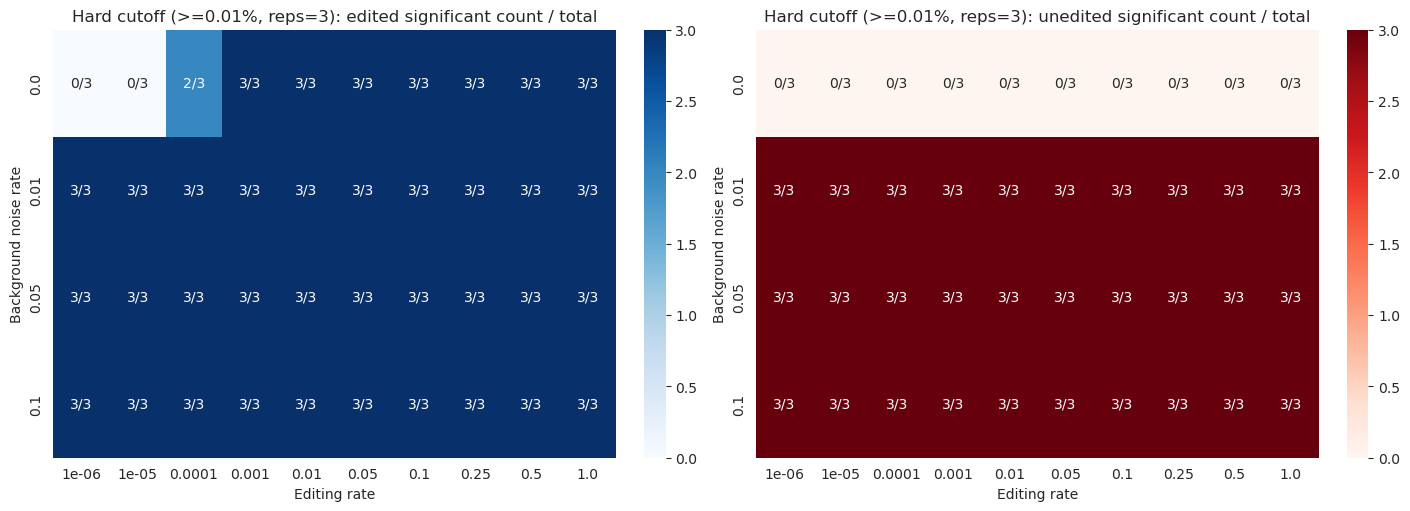

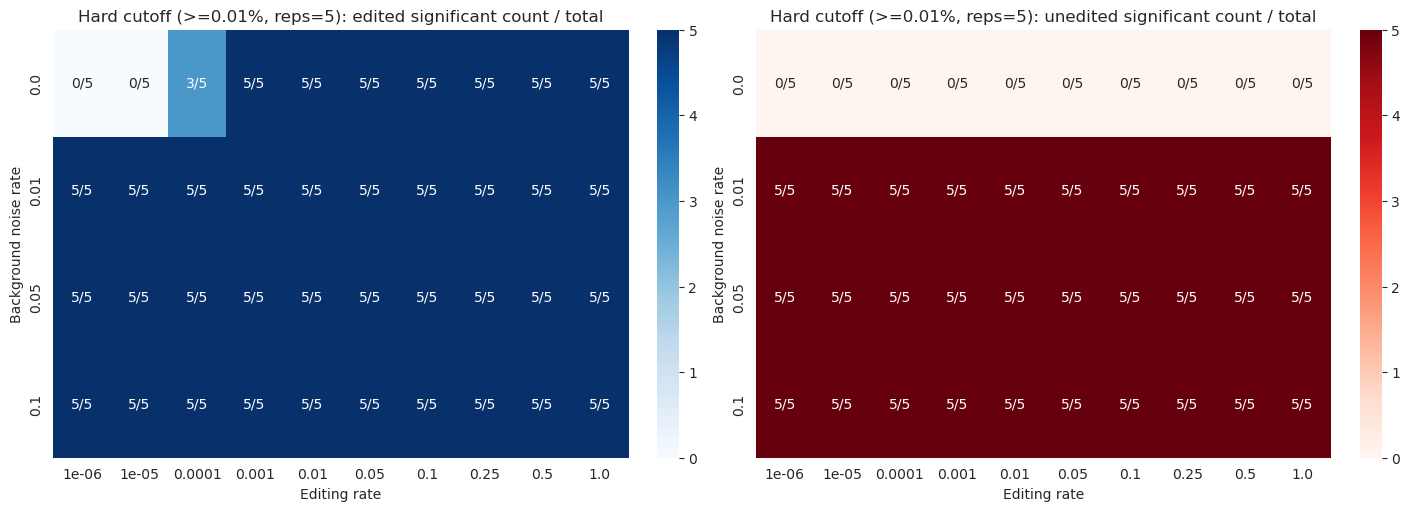

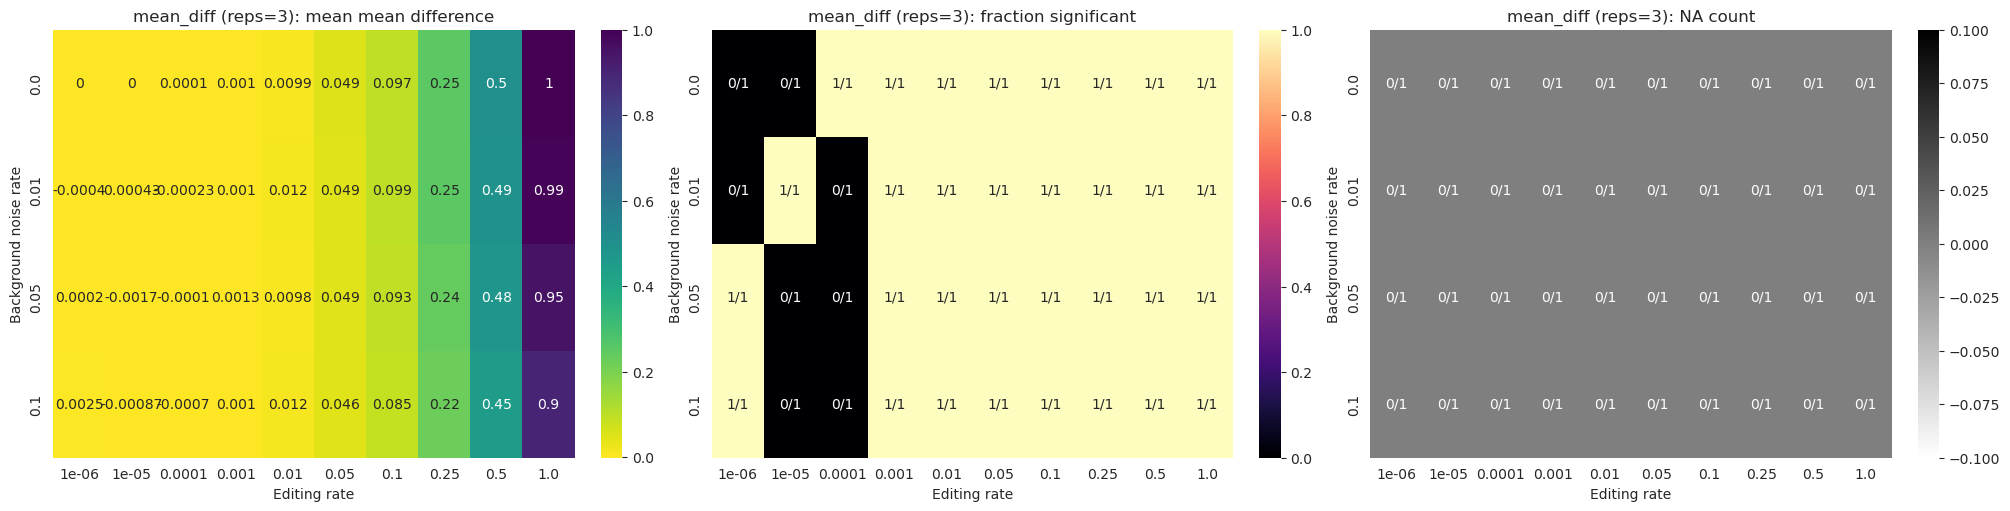

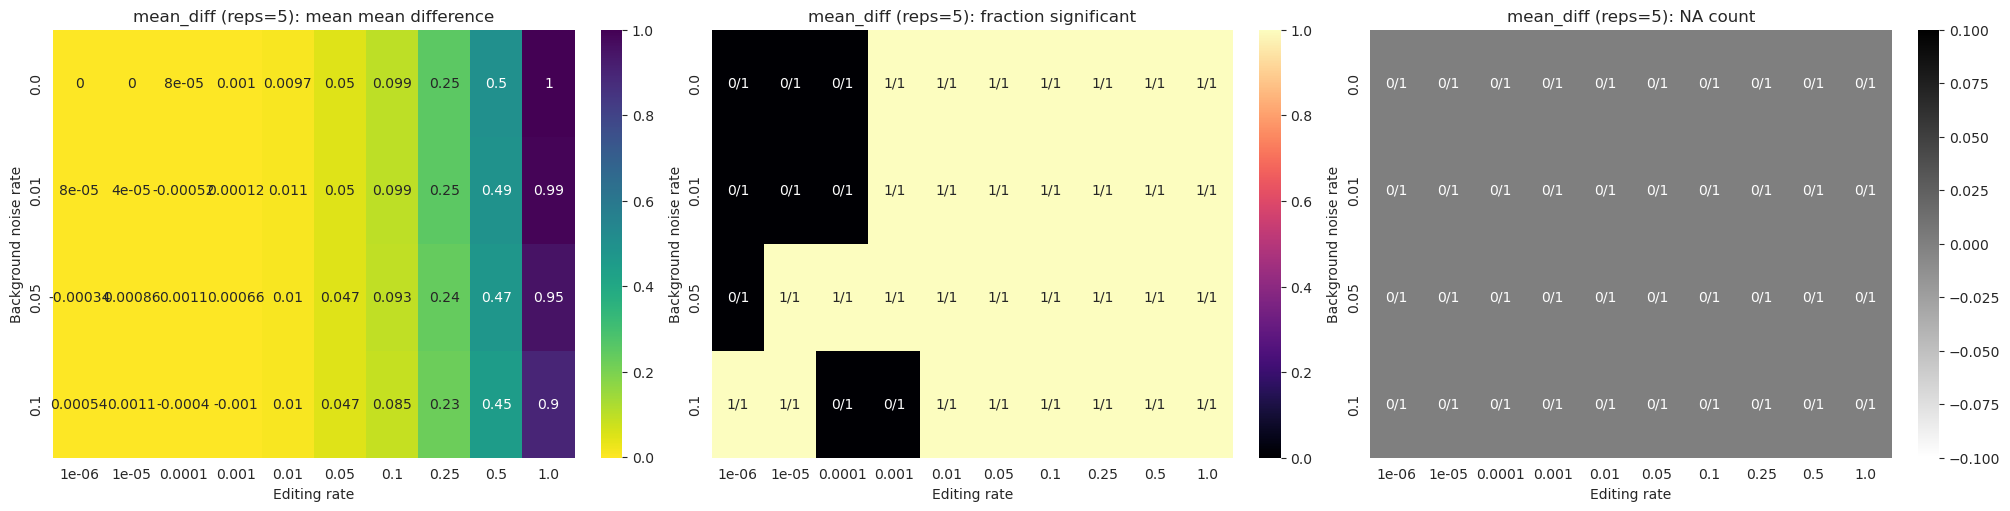

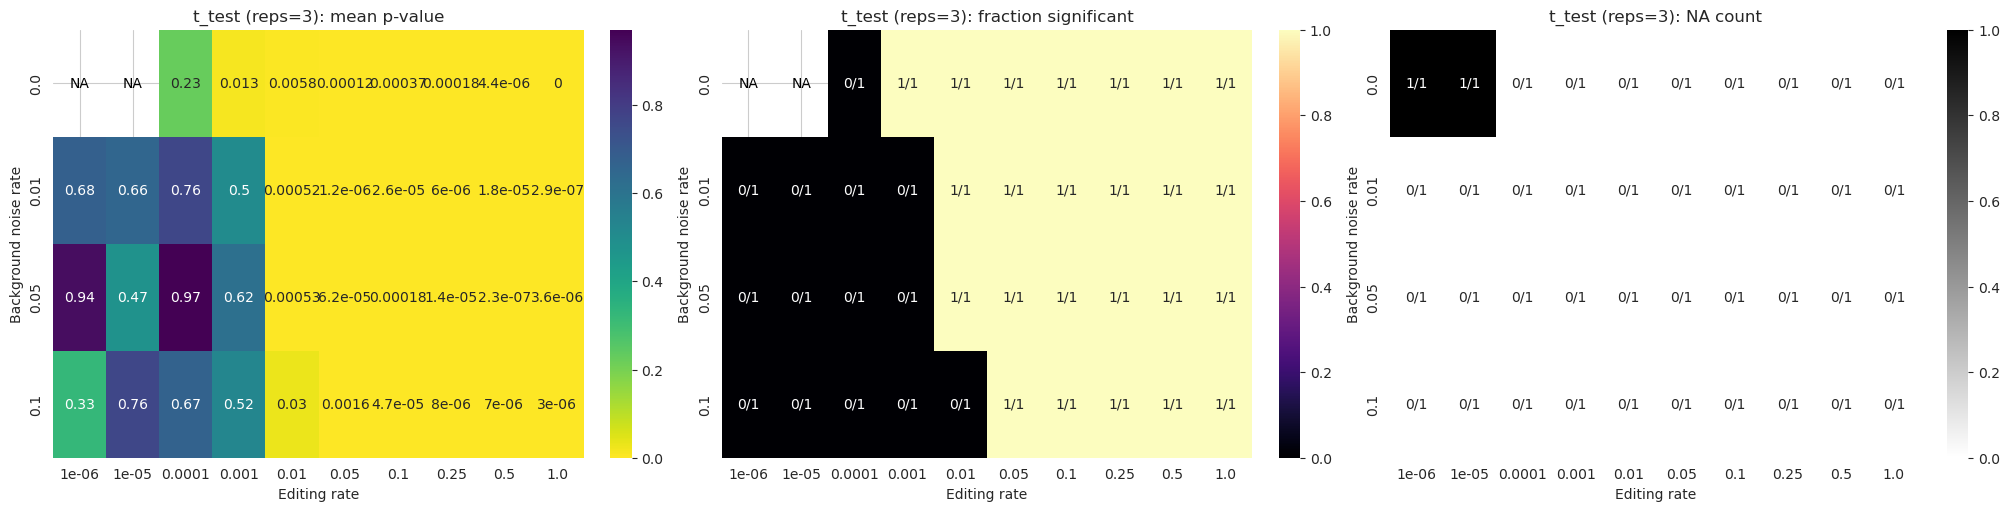

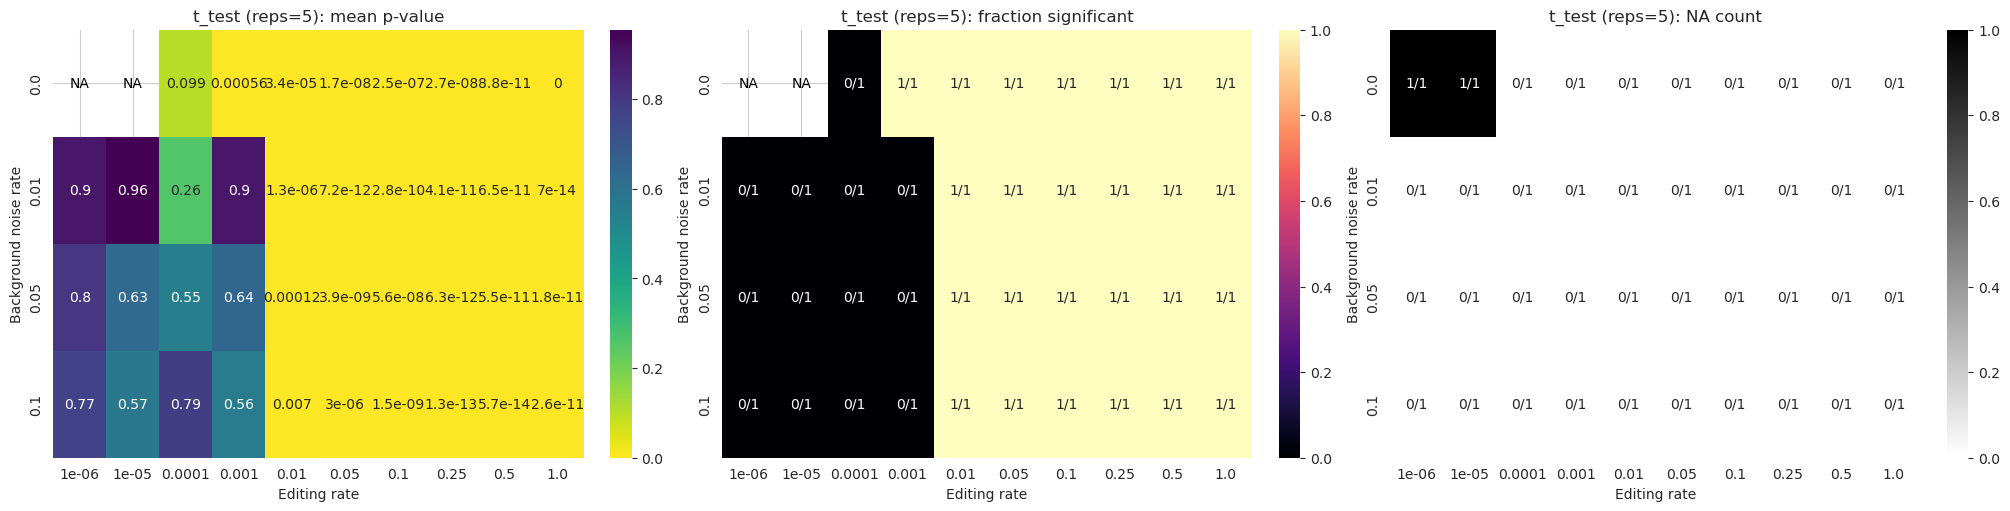

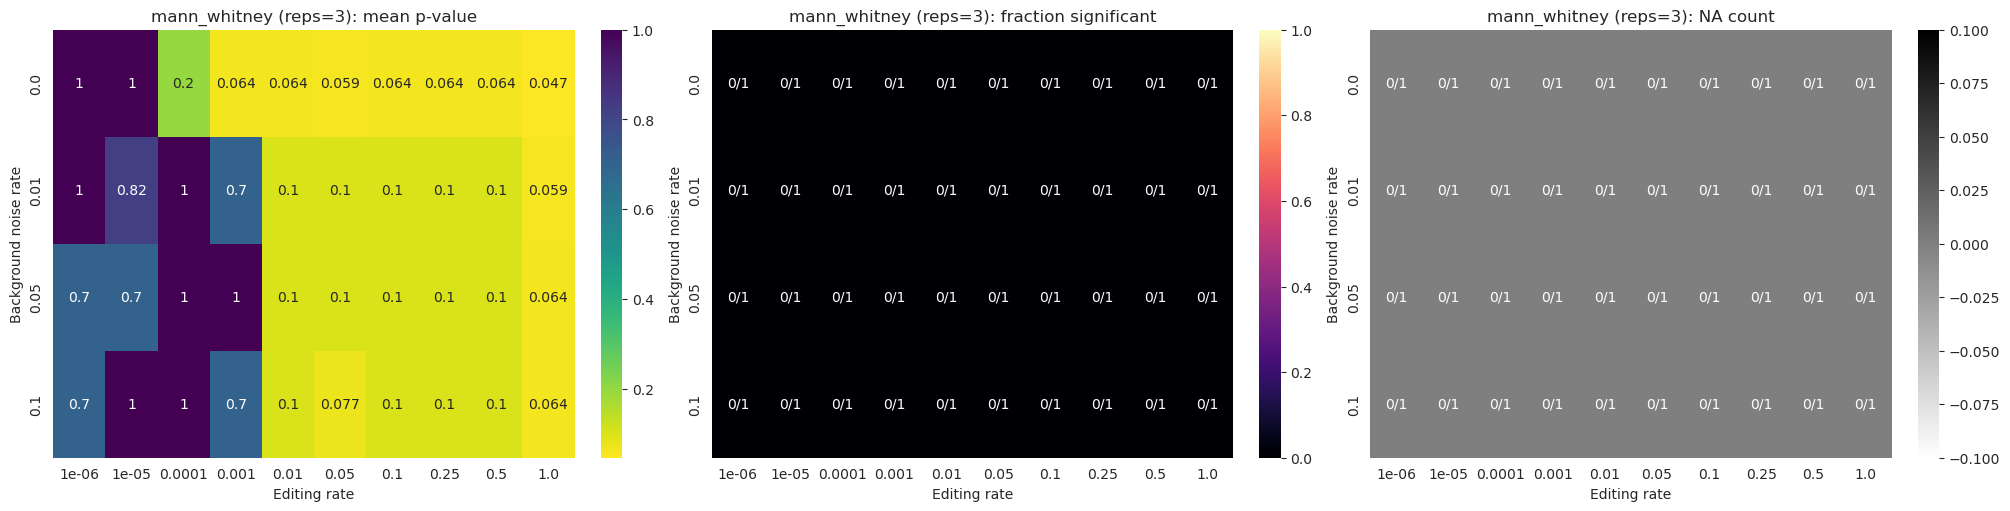

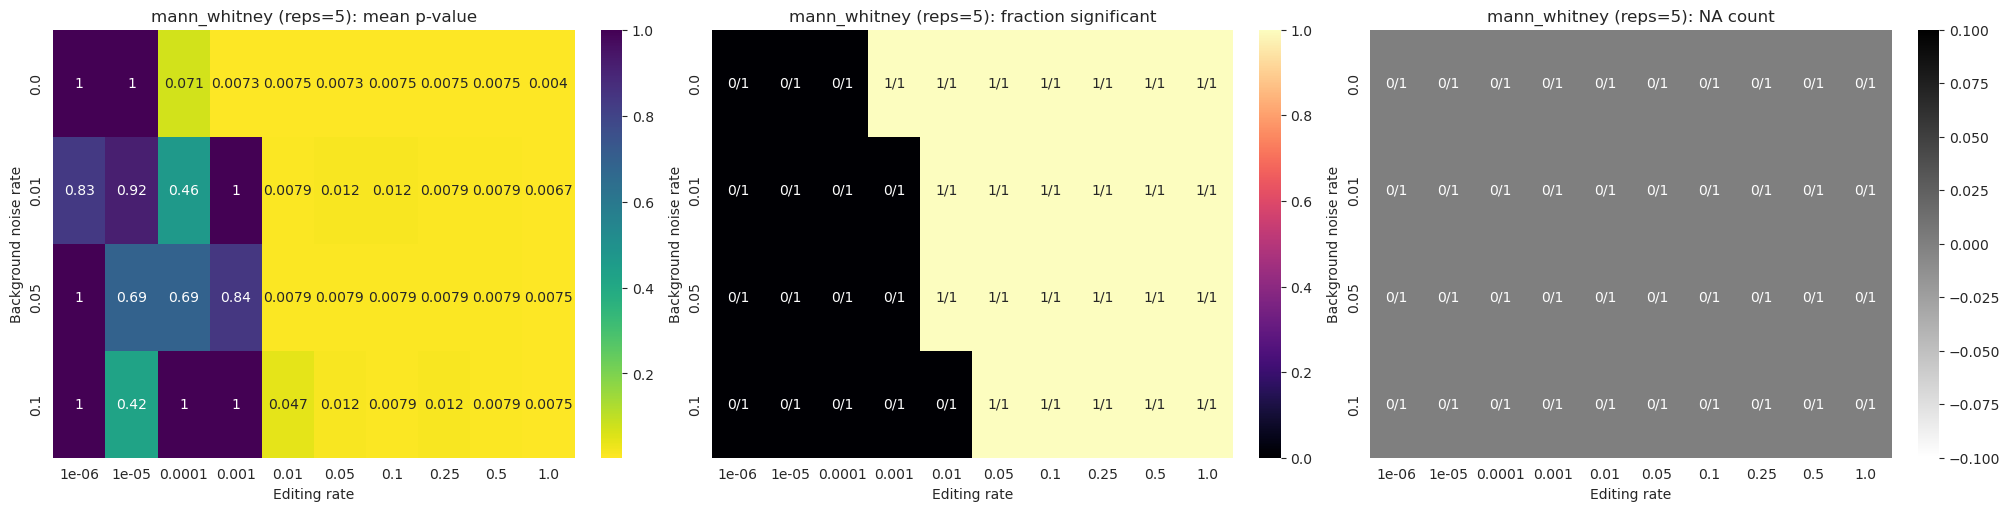

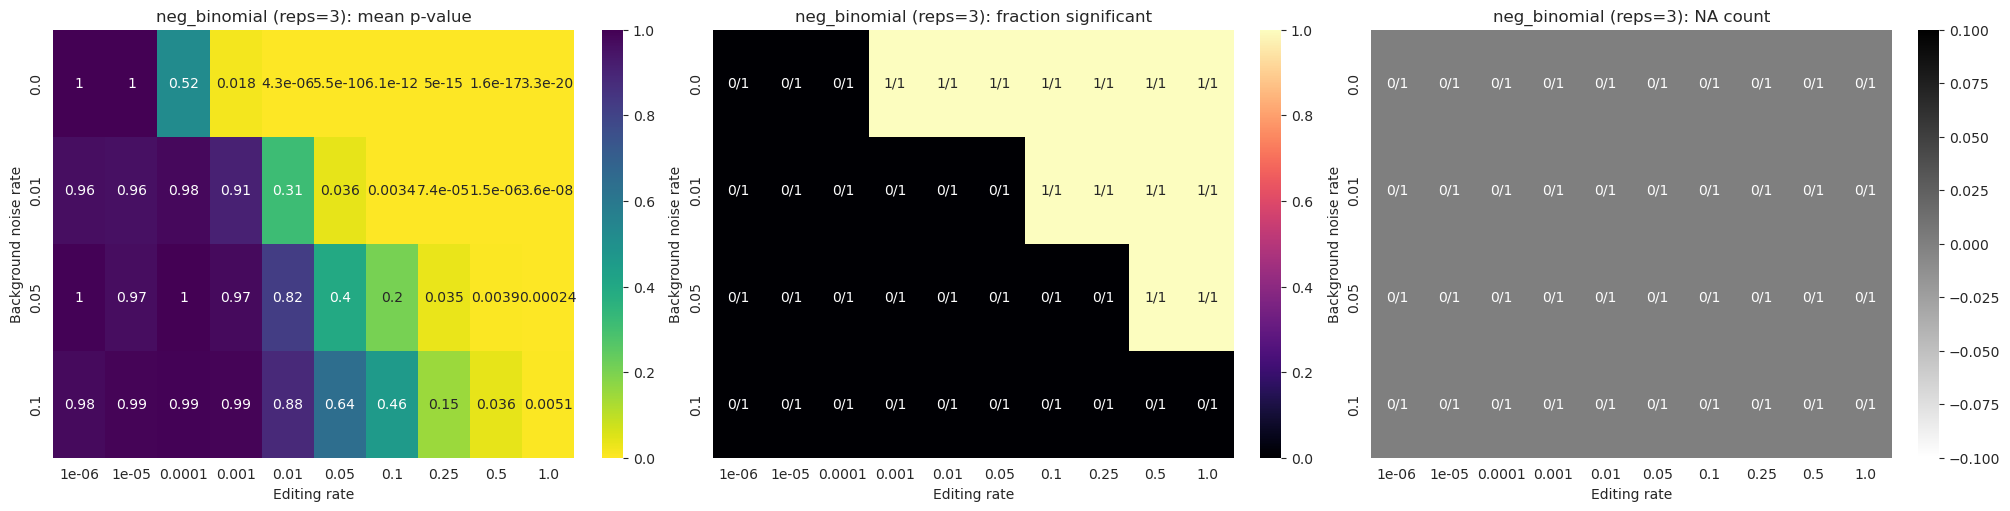

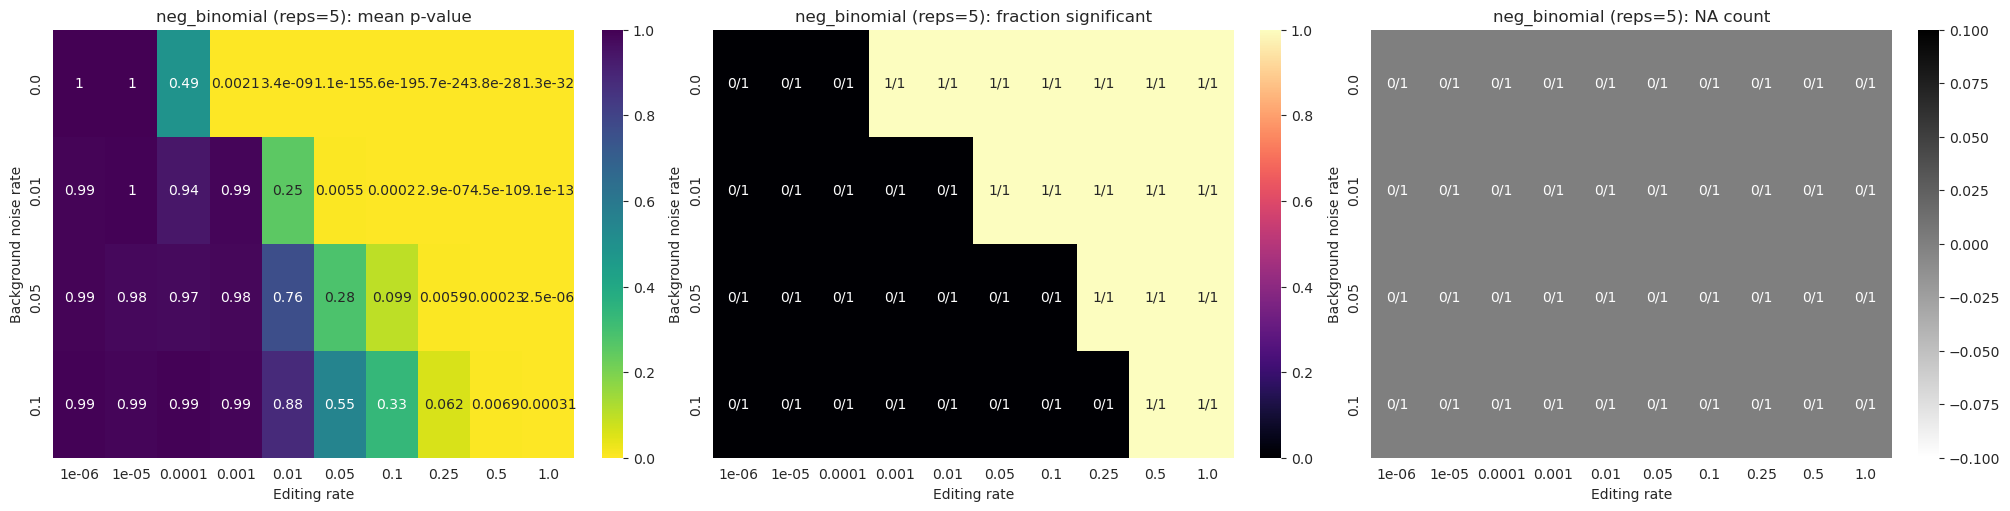

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")

def annotate_na_cells(ax, df):
    for i, row_idx in enumerate(df.index):
        for j, col_idx in enumerate(df.columns):
            if pd.isna(df.loc[row_idx, col_idx]):
                ax.text(j + 0.5, i + 0.5, "NA", ha="center", va="center", color="black")

plot_order = ["hard_cutoff", "mean_diff", "t_test", "mann_whitney", "neg_binomial"]

for sig_test_name in plot_order:
    if sig_test_name not in sig_test_summary_tables:
        continue

    df = sig_test_summary_tables[sig_test_name].copy()
    df["replicate_count"] = pd.to_numeric(df["replicate_count"], errors="coerce")
    df["background_noise_rate"] = pd.to_numeric(df["background_noise_rate"], errors="coerce")
    df["editing_rate"] = pd.to_numeric(df["editing_rate"], errors="coerce")

    for replicate_count in sorted(df["replicate_count"].dropna().unique()):
        rep_df = df.loc[df["replicate_count"] == replicate_count].copy()

        if sig_test_name == "hard_cutoff":
            rep_df["edited_total_n"] = pd.to_numeric(rep_df["edited_total_n"], errors="coerce")
            rep_df["unedited_total_n"] = pd.to_numeric(rep_df["unedited_total_n"], errors="coerce")
            rep_df["edited_significant_n"] = pd.to_numeric(rep_df["edited_significant_n"], errors="coerce")
            rep_df["unedited_significant_n"] = pd.to_numeric(rep_df["unedited_significant_n"], errors="coerce")

            fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

            edited_summary = rep_df.groupby(
                ["background_noise_rate", "editing_rate"], as_index=False
            )[["edited_significant_n", "edited_total_n"]].mean()

            edited_pivot = edited_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="edited_significant_n",
            ).astype(float)

            edited_total_pivot = edited_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="edited_total_n",
            ).astype(float)

            edited_annot = edited_pivot.copy().astype(object)
            for row_idx in edited_pivot.index:
                for col_idx in edited_pivot.columns:
                    sig_n = edited_pivot.loc[row_idx, col_idx]
                    total_n = edited_total_pivot.loc[row_idx, col_idx]
                    edited_annot.loc[row_idx, col_idx] = (
                        f"{int(round(sig_n))}/{int(round(total_n))}"
                        if pd.notna(sig_n) and pd.notna(total_n)
                        else "NA"
                    )

            unedited_summary = rep_df.groupby(
                ["background_noise_rate", "editing_rate"], as_index=False
            )[["unedited_significant_n", "unedited_total_n"]].mean()

            unedited_pivot = unedited_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="unedited_significant_n",
            ).astype(float)

            unedited_total_pivot = unedited_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="unedited_total_n",
            ).astype(float)

            unedited_annot = unedited_pivot.copy().astype(object)
            for row_idx in unedited_pivot.index:
                for col_idx in unedited_pivot.columns:
                    sig_n = unedited_pivot.loc[row_idx, col_idx]
                    total_n = unedited_total_pivot.loc[row_idx, col_idx]
                    unedited_annot.loc[row_idx, col_idx] = (
                        f"{int(round(sig_n))}/{int(round(total_n))}"
                        if pd.notna(sig_n) and pd.notna(total_n)
                        else "NA"
                    )

            sns.heatmap(
                edited_pivot,
                cmap="Blues",
                ax=axes[0],
                annot=edited_annot,
                fmt="",
            )
            annotate_na_cells(axes[0], edited_pivot)
            axes[0].set_title(
                f"Hard cutoff (>={hard_cutoff_pct:g}%, reps={int(replicate_count)}): edited significant count / total"
            )
            axes[0].set_xlabel("Editing rate")
            axes[0].set_ylabel("Background noise rate")

            sns.heatmap(
                unedited_pivot,
                cmap="Reds",
                ax=axes[1],
                annot=unedited_annot,
                fmt="",
            )
            annotate_na_cells(axes[1], unedited_pivot)
            axes[1].set_title(
                f"Hard cutoff (>={hard_cutoff_pct:g}%, reps={int(replicate_count)}): unedited significant count / total"
            )
            axes[1].set_xlabel("Editing rate")
            axes[1].set_ylabel("Background noise rate")

            plt.show()

        else:
            rep_df["pvalue"] = pd.to_numeric(rep_df["pvalue"], errors="coerce")
            rep_df["effect_value"] = pd.to_numeric(rep_df.get("effect_value", pd.NA), errors="coerce")
            rep_df["significant"] = pd.to_numeric(rep_df["significant"], errors="coerce")
            significance_mask_col = "effect_value" if sig_test_name == "mean_diff" else "pvalue"
            rep_df["significant_for_plot"] = rep_df["significant"].where(rep_df[significance_mask_col].notna(), pd.NA)
            rep_df["is_na"] = rep_df[significance_mask_col].isna().astype(float)

            fig, axes = plt.subplots(1, 3, figsize=(20, 5), constrained_layout=True)

            metric_col = "effect_value" if sig_test_name == "mean_diff" else "pvalue"
            metric_title = "mean mean difference" if sig_test_name == "mean_diff" else "mean p-value"

            pvalue_summary = rep_df.groupby(
                ["background_noise_rate", "editing_rate"], as_index=False
            ).agg(
                pvalue_mean=(metric_col, "mean"),
                pvalue_non_na_n=(metric_col, lambda x: x.notna().sum()),
                pvalue_total_n=(metric_col, "size"),
            )

            pvalue_pivot = pvalue_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="pvalue_mean",
            ).astype(float)

            pvalue_annot = pvalue_pivot.copy().astype(object)
            for row_idx in pvalue_pivot.index:
                for col_idx in pvalue_pivot.columns:
                    val = pvalue_pivot.loc[row_idx, col_idx]
                    pvalue_annot.loc[row_idx, col_idx] = (
                        f"{val:.2g}" if pd.notna(val) else "NA"
                    )

            significant_summary = rep_df.groupby(
                ["background_noise_rate", "editing_rate"], as_index=False
            ).agg(
                significant_sum=("significant_for_plot", "sum"),
                significant_total=("significant_for_plot", "count"),
                significant_fraction=("significant_for_plot", "mean"),
            )

            significant_pivot = significant_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="significant_fraction",
            ).astype(float)

            significant_sum_pivot = significant_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="significant_sum",
            ).astype(float)

            significant_total_pivot = significant_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="significant_total",
            ).astype(float)

            significant_annot = significant_pivot.copy().astype(object)
            for row_idx in significant_pivot.index:
                for col_idx in significant_pivot.columns:
                    sig_n = significant_sum_pivot.loc[row_idx, col_idx]
                    total_n = significant_total_pivot.loc[row_idx, col_idx]
                    significant_annot.loc[row_idx, col_idx] = (
                        f"{int(round(sig_n))}/{int(round(total_n))}"
                        if pd.notna(sig_n) and pd.notna(total_n)
                        else "NA"
                    )

            na_summary = rep_df.groupby(
                ["background_noise_rate", "editing_rate"], as_index=False
            ).agg(
                na_n=("is_na", "sum"),
                total_n=("is_na", "count"),
            )

            na_pivot = na_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="na_n",
            ).astype(float)

            na_n_pivot = na_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="na_n",
            ).astype(float)

            na_total_pivot = na_summary.pivot(
                index="background_noise_rate",
                columns="editing_rate",
                values="total_n",
            ).astype(float)

            na_annot = na_pivot.copy().astype(object)
            for row_idx in na_pivot.index:
                for col_idx in na_pivot.columns:
                    na_n = na_n_pivot.loc[row_idx, col_idx]
                    total_n = na_total_pivot.loc[row_idx, col_idx]
                    na_annot.loc[row_idx, col_idx] = (
                        f"{int(round(na_n))}/{int(round(total_n))}"
                        if pd.notna(na_n) and pd.notna(total_n)
                        else "NA"
                    )

            sns.heatmap(
                pvalue_pivot,
                cmap="viridis_r",
                ax=axes[0],
                annot=pvalue_annot,
                fmt="",
            )
            annotate_na_cells(axes[0], pvalue_pivot)
            axes[0].set_title(
                f"{sig_test_name} (reps={int(replicate_count)}): {metric_title}"
            )
            axes[0].set_xlabel("Editing rate")
            axes[0].set_ylabel("Background noise rate")

            sns.heatmap(
                significant_pivot,
                cmap="magma",
                vmin=0,
                vmax=1,
                ax=axes[1],
                annot=significant_annot,
                fmt="",
            )
            annotate_na_cells(axes[1], significant_pivot)
            axes[1].set_title(
                f"{sig_test_name} (reps={int(replicate_count)}): fraction significant"
            )
            axes[1].set_xlabel("Editing rate")
            axes[1].set_ylabel("Background noise rate")

            sns.heatmap(
                na_pivot,
                cmap="gray_r",
                ax=axes[2],
                annot=na_annot,
                fmt="",
            )
            annotate_na_cells(axes[2], na_pivot)
            axes[2].set_title(
                f"{sig_test_name} (reps={int(replicate_count)}): NA count"
            )
            axes[2].set_xlabel("Editing rate")
            axes[2].set_ylabel("Background noise rate")

            plt.show()
